# Questão 5 — Análise de Clientes

### Contexto

A diretoria quer identificar clientes fiéis — não quem comprou mais em volume, mas quem tem alto ticket médio por transação e compra em diversas categorias.

Métricas utilizadas:

| Métrica | Definição |
|---|---|
| Faturamento Total | Soma da coluna `total` por cliente |
| Frequência | Contagem de transações (IDs de venda) |
| Ticket Médio | Faturamento Total ÷ Frequência |
| Diversidade de Categorias | Quantidade de categorias distintas compradas |

Critério de elite: apenas clientes que compraram produtos de 3 ou mais categorias distintas.

---

Importações e leitura dos dados

In [1]:
import json
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Vendas
df_vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# Produtos
df_produtos = pd.read_csv('../data/raw/produtos_raw.csv')

# Clientes
with open('../data/raw/clientes_crm.json', 'r', encoding='utf-8') as f:
    df_clientes = pd.DataFrame(json.load(f))

print(f'Vendas:   {len(df_vendas)} registros')
print(f'Produtos: {len(df_produtos)} registros')
print(f'Clientes: {len(df_clientes)} registros')

Vendas:   9895 registros
Produtos: 157 registros
Clientes: 49 registros


Limpeza das categorias de produtos

In [2]:
def normalizar_categoria(texto):
    # Minúsculas e sem espaços internos
    t = texto.lower().replace(' ', '')
    # Remove acentos para comparação
    t = ''.join(
        c for c in unicodedata.normalize('NFD', t)
        if unicodedata.category(c) != 'Mn'
    )
    if t.startswith('elet'):               return 'eletrônicos'
    if t.startswith('prop'):               return 'propulsão'
    if t.startswith('anc') or t.startswith('enc'): return 'ancoragem'
    return t

df_produtos['categoria'] = df_produtos['actual_category'].apply(normalizar_categoria)

# Remove duplicatas de código de produto
df_produtos = df_produtos.drop_duplicates(subset='code', keep='first')

print('Categorias após normalização:')
print(df_produtos['categoria'].value_counts())

Categorias após normalização:
categoria
eletrônicos    50
propulsão      50
ancoragem      50
Name: count, dtype: int64


Corrigir datas e unir as tabelas

In [3]:
# Corrige os dois formatos de data coexistentes
def parse_date(s):
    for fmt in ('%Y-%m-%d', '%d-%m-%Y'):
        try: return pd.to_datetime(s, format=fmt)
        except: pass

df_vendas['sale_date'] = df_vendas['sale_date'].apply(parse_date)

# Join vendas com categoria do produto
df = df_vendas.merge(
    df_produtos[['code', 'categoria']],
    left_on='id_product',
    right_on='code',
    how='left'
)

print(f'Registros após join: {len(df)}')
df[['id', 'id_client', 'id_product', 'qtd', 'total', 'categoria']].head()

Registros após join: 9895


,id,id_client,id_product,qtd,total,categoria
0,0,42,105,11,3405.0,ancoragem
1,1,3,136,9,16873.9,ancoragem
2,2,25,139,7,9475.3,ancoragem
3,4,20,23,5,55893.0,eletrônicos
4,5,8,57,4,451403.9,propulsão


Calcular métricas por cliente

In [4]:
metricas = df.groupby('id_client').agg(
    faturamento_total        = ('total',     'sum'),
    frequencia               = ('id',        'count'),
    diversidade_categorias   = ('categoria', 'nunique')
).reset_index()

metricas['ticket_medio'] = metricas['faturamento_total'] / metricas['frequencia']

print(f'Clientes calculados: {len(metricas)}')
metricas.head()

Clientes calculados: 49


,id_client,faturamento_total,frequencia,diversidade_categorias,ticket_medio
0,1,51092500.05,190,3,268907.895000
1,2,65652931.35,220,3,298422.415227
2,3,59575349.10,207,3,287803.618841
3,4,50691754.40,207,3,244887.702415
4,5,58592802.70,202,3,290063.379703


Filtragem de clientes elite e gerando o ranking

Critérios:
- 3 ou mais categorias distintas compradas
- Ordenado por ticket médio decrescente
- Desempate por id_client crescente
- Top 10 clientes

In [5]:
top10 = (
    metricas[metricas['diversidade_categorias'] >= 3]
    .sort_values(['ticket_medio', 'id_client'], ascending=[False, True])
    .head(10)
    .reset_index(drop=True)
)

top10.index += 1  # ranking começa em 1

# Formata para exibição
top10_exibir = top10.copy()
top10_exibir['faturamento_total'] = top10_exibir['faturamento_total'].apply(lambda x: f'R$ {x:,.2f}')
top10_exibir['ticket_medio']      = top10_exibir['ticket_medio'].apply(lambda x: f'R$ {x:,.2f}')

top10_exibir[['id_client', 'faturamento_total', 'frequencia', 'ticket_medio', 'diversidade_categorias']]

,id_client,faturamento_total,frequencia,ticket_medio,diversidade_categorias
1,47,"R$ 64,003,343.75",190,"R$ 336,859.70",3
2,42,"R$ 72,187,369.50",222,"R$ 325,168.33",3
3,9,"R$ 66,788,855.35",218,"R$ 306,370.90",3
4,22,"R$ 59,581,398.75",198,"R$ 300,916.16",3
5,2,"R$ 65,652,931.35",220,"R$ 298,422.42",3
6,28,"R$ 60,826,837.25",204,"R$ 298,170.77",3
7,46,"R$ 59,126,834.35",199,"R$ 297,119.77",3
8,38,"R$ 57,093,331.15",195,"R$ 292,786.31",3
9,36,"R$ 62,791,038.15",215,"R$ 292,051.34",3
10,5,"R$ 58,592,802.70",202,"R$ 290,063.38",3


Categoria com mais itens comprados pelo grupo elite

In [6]:
ids_elite = top10['id_client'].tolist()

# Filtra vendas apenas dos clientes elite
df_elite = df[df['id_client'].isin(ids_elite)]

# Soma de itens por categoria
categoria_ranking = (
    df_elite.groupby('categoria')['qtd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
categoria_ranking.columns = ['categoria', 'total_itens']

print('Itens comprados pelo grupo elite por categoria:')
print(categoria_ranking.to_string(index=False))
print(f'\nCategoria dominante: {categoria_ranking.iloc[0]["categoria"]} ({categoria_ranking.iloc[0]["total_itens"]:,} itens)')

Itens comprados pelo grupo elite por categoria:
  categoria  total_itens
  propulsão         6030
  ancoragem         5632
eletrônicos         5214

Categoria dominante: propulsão (6,030 itens)


Visualização: Ticket Médio dos 10 clientes elite

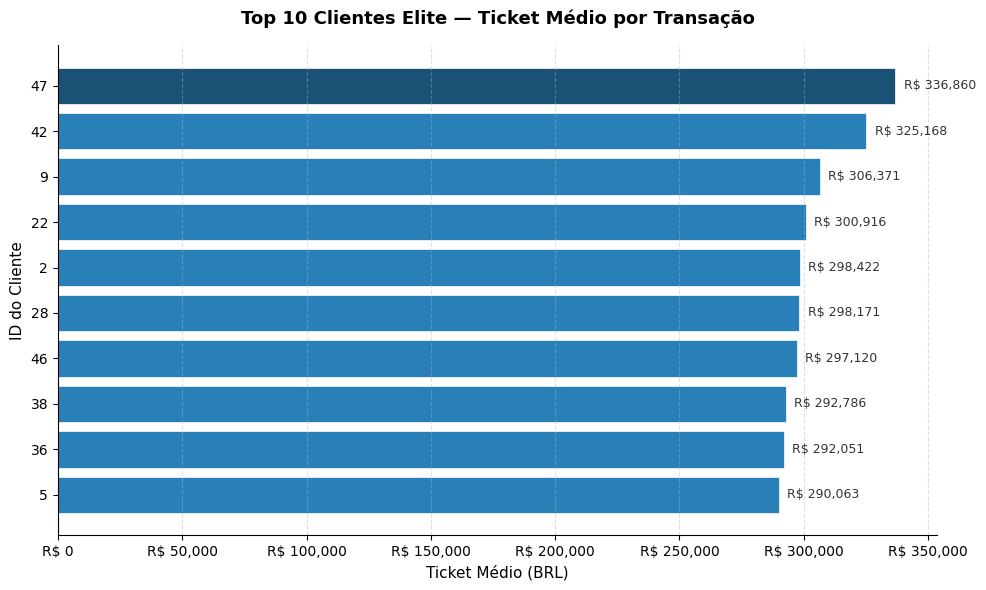

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

cores = ['#1a5276' if i == 0 else '#2980b9' for i in range(len(top10))]

bars = ax.barh(
    top10['id_client'].astype(str),
    top10['ticket_medio'],
    color=cores,
    edgecolor='white',
    linewidth=0.5
)

# Rótulo de valor em cada barra
for bar in bars:
    valor = bar.get_width()
    ax.text(
        valor + (top10['ticket_medio'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'R$ {valor:,.0f}',
        va='center', ha='left', fontsize=9, color='#333333'
    )

ax.invert_yaxis()
ax.set_xlabel('Ticket Médio (BRL)', fontsize=11)
ax.set_ylabel('ID do Cliente', fontsize=11)
ax.set_title('Top 10 Clientes Elite — Ticket Médio por Transação', fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Export dos resultados

In [8]:
import os
os.makedirs('../data/processed', exist_ok=True)

top10.reset_index(drop=True).to_csv('../data/processed/clientes_elite.csv', index=False)
print('Salvo: ../data/processed/clientes_elite.csv')

Salvo: ../data/processed/clientes_elite.csv


---
### Questão 5.1 — SQL: Clientes Fiéis

Pré-requisito: o notebook `05_clientes_elite.ipynb` deve ter sido rodado antes, pois ele cria as tabelas no banco `lighthouse.db`.

Caso ainda não tenha rodado, execute a célula abaixo para popular o banco.

---

Populando o banco SQLite

In [9]:
import sqlite3
import unicodedata
import pandas as pd

# Vendas
df_vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

def parse_date(s):
    for fmt in ('%Y-%m-%d', '%d-%m-%Y'):
        try: return pd.to_datetime(s, format=fmt)
        except: pass

df_vendas['sale_date'] = df_vendas['sale_date'].apply(parse_date)

# Produtos (com categoria normalizada)
df_produtos = pd.read_csv('../data/raw/produtos_raw.csv')

def normalizar_categoria(texto):
    t = texto.lower().replace(' ', '')
    t = ''.join(c for c in unicodedata.normalize('NFD', t) if unicodedata.category(c) != 'Mn')
    if t.startswith('elet'):                      return 'eletronicos'
    if t.startswith('prop'):                      return 'propulsao'
    if t.startswith('anc') or t.startswith('enc'): return 'ancoragem'
    return t

df_produtos['categoria'] = df_produtos['actual_category'].apply(normalizar_categoria)
df_produtos = df_produtos.drop_duplicates(subset='code', keep='first')
df_produtos['price'] = df_produtos['price'].str.replace('R$ ', '', regex=False).astype(float)

# Grava no banco
conn = sqlite3.connect('../database/lighthouse.db')

df_vendas.to_sql('vendas',   conn, if_exists='replace', index=False)
df_produtos.to_sql('produtos', conn, if_exists='replace', index=False)

print('Tabelas gravadas:')
for t in ['vendas', 'produtos']:
    n = conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    print(f'  {t}: {n} linhas')

Tabelas gravadas:
  vendas: 9895 linhas
  produtos: 150 linhas


---
Query 1 — Ticket Médio e Diversidade de Categorias por cliente

In [10]:
query_metricas = """
SELECT
    v.id_client,

    -- Faturamento total do cliente
    ROUND(SUM(v.total), 2)                  AS faturamento_total,

    -- Quantidade de transações
    COUNT(v.id)                             AS frequencia,

    -- Ticket médio = faturamento / frequência
    ROUND(SUM(v.total) / COUNT(v.id), 2)    AS ticket_medio,

    -- Categorias distintas compradas
    COUNT(DISTINCT p.categoria)             AS diversidade_categorias

FROM vendas v
JOIN produtos p ON v.id_product = p.code

GROUP BY v.id_client
ORDER BY ticket_medio DESC;
"""

df_metricas = pd.read_sql(query_metricas, conn)

print(f'Clientes calculados: {len(df_metricas)}')
df_metricas.head(10)

Clientes calculados: 49


,id_client,faturamento_total,frequencia,ticket_medio,diversidade_categorias
0,47,64003343.75,190,336859.70,3
1,42,72187369.50,222,325168.33,3
2,9,66788855.35,218,306370.90,3
3,22,59581398.75,198,300916.16,3
4,2,65652931.35,220,298422.42,3
5,28,60826837.25,204,298170.77,3
6,46,59126834.35,199,297119.77,3
7,38,57093331.15,195,292786.31,3
8,36,62791038.15,215,292051.34,3
9,5,58592802.70,202,290063.38,3


Query 2 — Top 10 clientes fiéis (diversidade >= 3, maior ticket médio)

Foi feita uma subquery para primeiro calcular as métricas e depois aplicar o filtro e o limite.

In [11]:
query_elite = """
SELECT *
FROM (
    SELECT
        v.id_client,
        ROUND(SUM(v.total), 2)               AS faturamento_total,
        COUNT(v.id)                          AS frequencia,
        ROUND(SUM(v.total) / COUNT(v.id), 2) AS ticket_medio,
        COUNT(DISTINCT p.categoria)          AS diversidade_categorias
    FROM vendas v
    JOIN produtos p ON v.id_product = p.code
    GROUP BY v.id_client
)

-- Filtro de elite: 3 ou mais categorias distintas
WHERE diversidade_categorias >= 3

-- Desempate: ticket médio desc, id_client asc
ORDER BY ticket_medio DESC, id_client ASC

LIMIT 10;
"""

df_elite = pd.read_sql(query_elite, conn)

df_elite.index += 1  # ranking começa em 1
df_elite

,id_client,faturamento_total,frequencia,ticket_medio,diversidade_categorias
1,47,64003343.75,190,336859.70,3
2,42,72187369.50,222,325168.33,3
3,9,66788855.35,218,306370.90,3
4,22,59581398.75,198,300916.16,3
5,2,65652931.35,220,298422.42,3
6,28,60826837.25,204,298170.77,3
7,46,59126834.35,199,297119.77,3
8,38,57093331.15,195,292786.31,3
9,36,62791038.15,215,292051.34,3
10,5,58592802.70,202,290063.38,3


Query 3 — Categoria mais comprada pelo grupo elite (em quantidade de itens)

In [12]:
query_categoria = """
SELECT
    p.categoria,
    SUM(v.qtd) AS total_itens

FROM vendas v
JOIN produtos p ON v.id_product = p.code

-- Filtra apenas os 10 clientes elite
WHERE v.id_client IN (
    SELECT id_client
    FROM (
        SELECT
            v2.id_client,
            SUM(v2.total) / COUNT(v2.id) AS ticket_medio,
            COUNT(DISTINCT p2.categoria) AS diversidade_categorias
        FROM vendas v2
        JOIN produtos p2 ON v2.id_product = p2.code
        GROUP BY v2.id_client
    )
    WHERE diversidade_categorias >= 3
    ORDER BY ticket_medio DESC, id_client ASC
    LIMIT 10
)

GROUP BY p.categoria
ORDER BY total_itens DESC;
"""

df_categoria = pd.read_sql(query_categoria, conn)

print('Categorias compradas pelo grupo elite:')
print(df_categoria.to_string(index=False))
print(f'\nCategoria dominante: {df_categoria.iloc[0]["categoria"]} ({df_categoria.iloc[0]["total_itens"]:,} itens)')

Categorias compradas pelo grupo elite:
  categoria  total_itens
  propulsao         6030
  ancoragem         5632
eletronicos         5214

Categoria dominante: propulsao (6,030 itens)


In [13]:
conn.close()

---
### Querys SQLite

```bash
sqlite3 database/lighthouse.db
```

Query 1 — Métricas por cliente:
```sql
SELECT
    v.id_client,
    ROUND(SUM(v.total), 2)               AS faturamento_total,
    COUNT(v.id)                          AS frequencia,
    ROUND(SUM(v.total) / COUNT(v.id), 2) AS ticket_medio,
    COUNT(DISTINCT p.categoria)          AS diversidade_categorias
FROM vendas v
JOIN produtos p ON v.id_product = p.code
GROUP BY v.id_client
ORDER BY ticket_medio DESC;
```

Query 2 — Top 10 clientes fiéis:
```sql
SELECT * FROM (
    SELECT
        v.id_client,
        ROUND(SUM(v.total), 2)               AS faturamento_total,
        COUNT(v.id)                          AS frequencia,
        ROUND(SUM(v.total) / COUNT(v.id), 2) AS ticket_medio,
        COUNT(DISTINCT p.categoria)          AS diversidade_categorias
    FROM vendas v
    JOIN produtos p ON v.id_product = p.code
    GROUP BY v.id_client
)
WHERE diversidade_categorias >= 3
ORDER BY ticket_medio DESC, id_client ASC
LIMIT 10;
```

Query 3 — Categoria dominante do grupo elite:
```sql
SELECT p.categoria, SUM(v.qtd) AS total_itens
FROM vendas v
JOIN produtos p ON v.id_product = p.code
WHERE v.id_client IN (
    SELECT id_client FROM (
        SELECT v2.id_client,
               SUM(v2.total) / COUNT(v2.id) AS ticket_medio,
               COUNT(DISTINCT p2.categoria) AS diversidade_categorias
        FROM vendas v2
        JOIN produtos p2 ON v2.id_product = p2.code
        GROUP BY v2.id_client
    )
    WHERE diversidade_categorias >= 3
    ORDER BY ticket_medio DESC, id_client ASC
    LIMIT 10
)
GROUP BY p.categoria
ORDER BY total_itens DESC;
```

### Questão 5.2 - Validação
Considerando apenas as compras realizadas pelos Top 10 Clientes selecionados (Critério: Maior Ticket Médio com 3+ categorias): Qual foi a categoria de produtos mais vendida para eles (maior quantidade total de itens)?

A categoria mais vendida para os Top 10 clientes foi propulsão, com 6.030 itens no total.

### Questão 5.3 - Explique:
Como você realizou a limpeza das categorias?
Qual lógica utilizou para filtrar os clientes com diversidade mínima?
Como garantiu que a contagem de itens refletisse apenas os Top 10?

A limpeza das categorias foi feita convertendo cada valor para minúsculas, removendo espaços internos e acentos, e então classificando pelo prefixo do texto resultante — qualquer variação começando com elet vira eletrônicos, com prop vira propulsão, e com anc ou enc vira ancoragem, cobrindo inclusive erros como "Encoragem" e "Eletronicoz". Para o filtro de diversidade mínima, as métricas foram calculadas com COUNT(DISTINCT categoria) agrupado por cliente, e o filtro WHERE diversidade_categorias >= 3 foi aplicado em seguida com uma subquery, já que o SQLite não permite usar `alias` de agregação diretamente no WHERE. A contagem de itens foi restrita aos Top 10 usando WHERE id_client IN (...), onde a subquery interna reproduz exatamente a mesma lógica de seleção — mesmos critérios de filtro, mesma ordenação por ticket médio decrescente com desempate por id_client crescente e LIMIT 10 — garantindo que apenas as compras desse grupo específico entrassem no SUM(qtd).
